# GDP Shock-Adjusted Robustness (Ex-Post)

This notebook builds a **supplementary shock-adjusted model** for demonstration and robustness analysis.

Important interpretation:
- This notebook does **not replace** the main holdout-test leaderboard.
- The main leaderboard remains the fair forecasting benchmark.
- This notebook is an **ex-post robustness check** that asks:
  - If the model is allowed to learn explicit shock-year effects, can it explain the 2020 crash and 2021 rebound better?

Why ex-post?
- A pre-2018 training sample cannot estimate COVID shock coefficients because those years do not exist in training.
- Therefore, this robustness model is fitted on the full available panel and used for explanation, not for replacing the official winner.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 7)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)


Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned


In [2]:
model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]

panel_df = pd.read_csv(DATA_PATH, usecols=model_cols).dropna().copy()
panel_df["year"] = pd.to_numeric(panel_df["year"], errors="coerce").astype(int)
panel_df["target_year"] = panel_df["year"] + 1
panel_df["year_trend"] = panel_df["year"] - panel_df["year"].min()

# Target-year shock dummies are created from the year being predicted.
panel_df["target_year_covid_shock_2020"] = (panel_df["target_year"] == 2020).astype(int)
panel_df["target_year_covid_rebound_2021"] = (panel_df["target_year"] == 2021).astype(int)
panel_df["target_year_ukraine_energy_shock_2022_2024"] = (
    panel_df["target_year"].between(2022, 2024)
).astype(int)
panel_df["target_year_high_global_rates_2023_2024"] = (
    panel_df["target_year"].between(2023, 2024)
).astype(int)

print("Panel shape:", panel_df.shape)
print("Countries:", panel_df["country_code"].nunique())
print("Regions:", panel_df["wb_region"].nunique())
print("Feature-year range:", int(panel_df["year"].min()), "-", int(panel_df["year"].max()))
print("Target-year range:", int(panel_df["target_year"].min()), "-", int(panel_df["target_year"].max()))

panel_df.head()


Panel shape: (4722, 19)
Countries: 177
Regions: 7
Feature-year range: 1991 - 2022
Target-year range: 1992 - 2023


,country_name,country_code,wb_region,year,life_expectancy_years,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,asian_financial_crisis_9798,global_financial_crisis_0809,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,target_year,year_trend,target_year_covid_shock_2020,target_year_covid_rebound_2021,target_year_ukraine_energy_shock_2022_2024,target_year_high_global_rates_2023_2024
43,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2005,58.2470,5.5381,17.0103,5.6139,0,0,12.6863,7.8780,1.2241,2006,14,0,0,0,0
44,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2006,58.5530,5.6139,17.0512,5.9302,0,0,6.7846,7.8970,2.1071,2007,15,0,0,0,0
45,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2007,58.9560,5.9302,17.0701,5.9447,0,0,8.6806,7.8410,1.9000,2008,16,0,0,0,0
46,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2008,59.7080,5.9447,17.0920,6.1138,0,1,26.4187,7.8790,1.8400,2009,17,0,0,0,0
47,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2009,60.2480,6.1138,17.1285,6.3290,0,1,-2.8285,7.8080,3.5500,2010,18,0,0,0,0


In [3]:
BASE_FORMULA = (
    "target_log_gdp_next_year ~ "
    "log_gdp_per_capita + log_population_total + life_expectancy_years "
    "+ inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean "
    "+ asian_financial_crisis_9798 + global_financial_crisis_0809 "
    "+ C(wb_region) + year_trend"
)

SHOCK_FORMULA = (
    "target_log_gdp_next_year ~ "
    "log_gdp_per_capita + log_population_total + life_expectancy_years "
    "+ inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean "
    "+ asian_financial_crisis_9798 + global_financial_crisis_0809 "
    "+ target_year_covid_shock_2020 + target_year_covid_rebound_2021 "
    "+ target_year_ukraine_energy_shock_2022_2024 + target_year_high_global_rates_2023_2024 "
    "+ C(wb_region) + year_trend"
)

base_model = smf.ols(BASE_FORMULA, data=panel_df).fit(cov_type="HC3")
shock_model = smf.ols(SHOCK_FORMULA, data=panel_df).fit(cov_type="HC3")

print("Base model R-squared:", round(base_model.rsquared, 6))
print("Shock-adjusted model R-squared:", round(shock_model.rsquared, 6))
print("Base model AIC:", round(base_model.aic, 4))
print("Shock-adjusted model AIC:", round(shock_model.aic, 4))
print("Base model BIC:", round(base_model.bic, 4))
print("Shock-adjusted model BIC:", round(shock_model.bic, 4))


Base model R-squared: 0.99334
Shock-adjusted model R-squared: 0.993648
Base model AIC: -6104.7829
Shock-adjusted model AIC: -6320.1236
Base model BIC: -6001.4231
Shock-adjusted model BIC: -6190.9238


In [4]:
def level_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def build_prediction_frame(model, frame, model_label):
    out = frame.copy()
    out["model_label"] = model_label
    out["predicted_log_gdp_next_year"] = model.predict(out)
    out["actual_gdp_next_year"] = np.exp(out["target_log_gdp_next_year"])
    out["predicted_gdp_next_year"] = np.exp(out["predicted_log_gdp_next_year"])
    out["absolute_error_usd"] = np.abs(out["actual_gdp_next_year"] - out["predicted_gdp_next_year"])
    out["absolute_percentage_error_pct"] = (
        out["absolute_error_usd"] / out["actual_gdp_next_year"]
    ) * 100
    return out


base_pred_df = build_prediction_frame(base_model, panel_df, "Base full dynamic")
shock_pred_df = build_prediction_frame(shock_model, panel_df, "Shock-adjusted supplementary")

fit_metrics_df = pd.DataFrame([
    {
        "model_label": "Base full dynamic",
        "n_obs": len(base_pred_df),
        "AIC": base_model.aic,
        "BIC": base_model.bic,
        **level_metrics(base_pred_df["actual_gdp_next_year"], base_pred_df["predicted_gdp_next_year"]),
    },
    {
        "model_label": "Shock-adjusted supplementary",
        "n_obs": len(shock_pred_df),
        "AIC": shock_model.aic,
        "BIC": shock_model.bic,
        **level_metrics(shock_pred_df["actual_gdp_next_year"], shock_pred_df["predicted_gdp_next_year"]),
    },
]).round(4)

fit_metrics_df


,model_label,n_obs,AIC,BIC,MAE,RMSE,MAPE_pct,R_squared
0,Base full dynamic,4722,"-6,104.7829","-6,001.4231","1,006.7025","2,399.3517",8.7983,0.9830
1,Shock-adjusted supplementary,4722,"-6,320.1236","-6,190.9238",959.0168,"2,270.3584",8.5249,0.9848


In [5]:
shock_terms = [
    "target_year_covid_shock_2020",
    "target_year_covid_rebound_2021",
    "target_year_ukraine_energy_shock_2022_2024",
    "target_year_high_global_rates_2023_2024",
]

coef_ci = shock_model.conf_int()
shock_coef_df = pd.DataFrame({
    "term": shock_terms,
    "coefficient": [shock_model.params.get(term, np.nan) for term in shock_terms],
    "std_error": [shock_model.bse.get(term, np.nan) for term in shock_terms],
    "p_value": [shock_model.pvalues.get(term, np.nan) for term in shock_terms],
    "ci_lower": [coef_ci.loc[term, 0] if term in coef_ci.index else np.nan for term in shock_terms],
    "ci_upper": [coef_ci.loc[term, 1] if term in coef_ci.index else np.nan for term in shock_terms],
}).round(6)

shock_coef_df


,term,coefficient,std_error,p_value,ci_lower,ci_upper
0,target_year_covid_shock_2020,-0.1044,0.0095,0.0000,-0.1231,-0.0856
1,target_year_covid_rebound_2021,0.0961,0.0090,0.0000,0.0785,0.1138
2,target_year_ukraine_energy_shock_2022_2024,0.0313,0.0100,0.0017,0.0117,0.0509
3,target_year_high_global_rates_2023_2024,-0.0091,0.0123,0.4602,-0.0331,0.0150


In [6]:
yearly_base_df = (
    base_pred_df.groupby("target_year", as_index=False)
    .agg(
        actual_mean_gdp=("actual_gdp_next_year", "mean"),
        predicted_mean_gdp=("predicted_gdp_next_year", "mean"),
        mean_absolute_percentage_error_pct=("absolute_percentage_error_pct", "mean"),
    )
)
yearly_base_df["model_label"] = "Base full dynamic"

yearly_shock_df = (
    shock_pred_df.groupby("target_year", as_index=False)
    .agg(
        actual_mean_gdp=("actual_gdp_next_year", "mean"),
        predicted_mean_gdp=("predicted_gdp_next_year", "mean"),
        mean_absolute_percentage_error_pct=("absolute_percentage_error_pct", "mean"),
    )
)
yearly_shock_df["model_label"] = "Shock-adjusted supplementary"

yearly_compare_df = pd.concat([yearly_base_df, yearly_shock_df], ignore_index=True)
yearly_compare_df = yearly_compare_df[yearly_compare_df["target_year"].between(2019, 2023)].copy()
yearly_compare_df["absolute_gap_usd"] = np.abs(
    yearly_compare_df["predicted_mean_gdp"] - yearly_compare_df["actual_mean_gdp"]
)
yearly_compare_df["pred_to_actual_ratio"] = (
    yearly_compare_df["predicted_mean_gdp"] / yearly_compare_df["actual_mean_gdp"]
)

base_gap = yearly_compare_df[
    yearly_compare_df["model_label"] == "Base full dynamic"
][["target_year", "absolute_gap_usd"]].rename(columns={"absolute_gap_usd": "base_gap_usd"})

shock_gap = yearly_compare_df[
    yearly_compare_df["model_label"] == "Shock-adjusted supplementary"
][["target_year", "absolute_gap_usd"]].rename(columns={"absolute_gap_usd": "shock_gap_usd"})

gap_reduction_df = base_gap.merge(shock_gap, on="target_year", how="inner")
gap_reduction_df["gap_reduction_usd"] = gap_reduction_df["base_gap_usd"] - gap_reduction_df["shock_gap_usd"]
gap_reduction_df["gap_reduction_pct"] = (
    gap_reduction_df["gap_reduction_usd"] / gap_reduction_df["base_gap_usd"]
) * 100
gap_reduction_df = gap_reduction_df.round(4)

yearly_compare_df = yearly_compare_df.round(4)
display(yearly_compare_df)
display(gap_reduction_df)


,target_year,actual_mean_gdp,predicted_mean_gdp,mean_absolute_percentage_error_pct,model_label,absolute_gap_usd,pred_to_actual_ratio
27,2019,"15,698.9605","16,322.2820",5.2950,Base full dynamic,623.3215,1.0397
28,2020,"14,549.3612","16,082.2806",12.8234,Base full dynamic,"1,532.9194",1.1054
29,2021,"17,155.0981","15,109.1983",10.2731,Base full dynamic,"2,045.8998",0.8807
30,2022,"18,048.6179","17,684.3299",8.1097,Base full dynamic,364.2879,0.9798
31,2023,"18,914.0876","18,471.0834",7.5337,Base full dynamic,443.0042,0.9766
59,2019,"15,698.9605","16,240.2290",5.0016,Shock-adjusted supplementary,541.2685,1.0345
60,2020,"14,549.3612","14,411.3324",8.3718,Shock-adjusted supplementary,138.0288,0.9905
61,2021,"17,155.0981","16,535.5155",6.9781,Shock-adjusted supplementary,619.5826,0.9639
62,2022,"18,048.6179","18,130.7974",8.3153,Shock-adjusted supplementary,82.1796,1.0046
63,2023,"18,914.0876","18,761.2230",7.3633,Shock-adjusted supplementary,152.8647,0.9919


,target_year,base_gap_usd,shock_gap_usd,gap_reduction_usd,gap_reduction_pct
0,2019,623.3215,541.2685,82.0530,13.1638
1,2020,"1,532.9194",138.0288,"1,394.8906",90.9957
2,2021,"2,045.8998",619.5826,"1,426.3172",69.7159
3,2022,364.2879,82.1796,282.1083,77.4410
4,2023,443.0042,152.8647,290.1396,65.4936


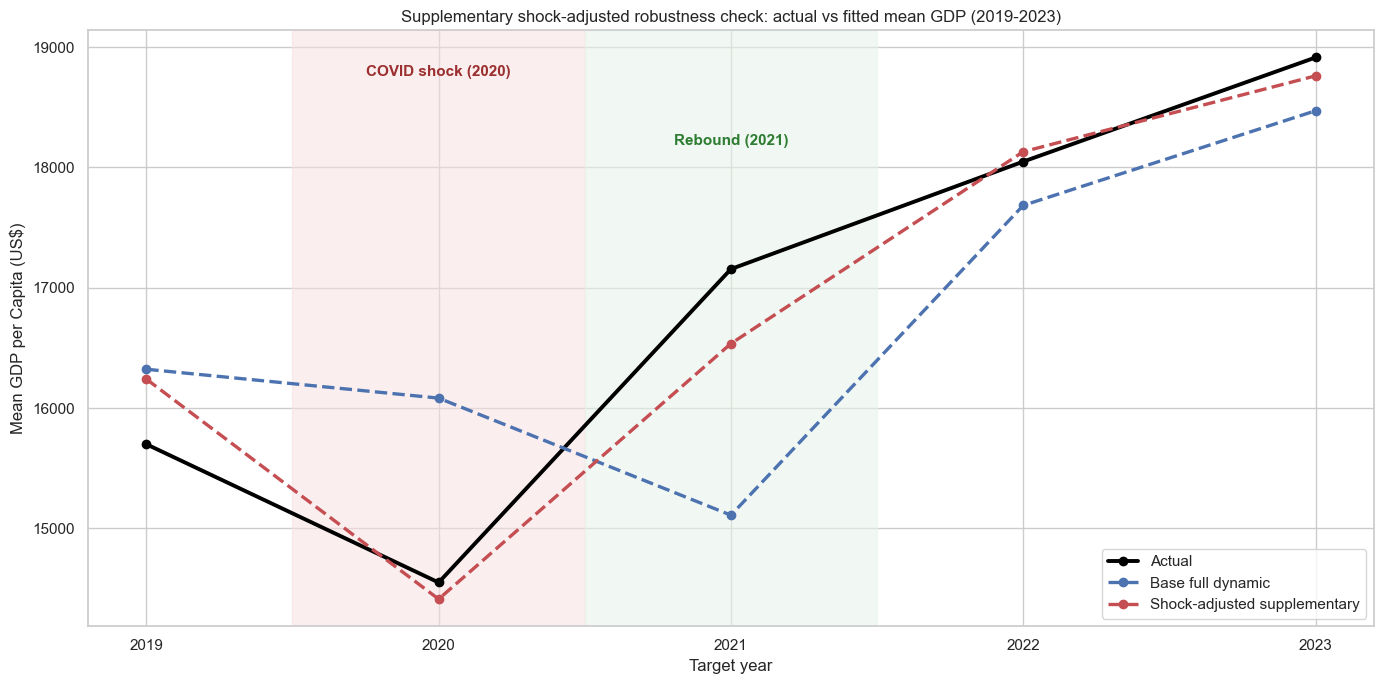

In [7]:
actual_plot_df = yearly_compare_df[
    yearly_compare_df["model_label"] == "Base full dynamic"
].sort_values("target_year")

base_plot_df = yearly_compare_df[
    yearly_compare_df["model_label"] == "Base full dynamic"
].sort_values("target_year")

shock_plot_df = yearly_compare_df[
    yearly_compare_df["model_label"] == "Shock-adjusted supplementary"
].sort_values("target_year")

years = actual_plot_df["target_year"].astype(int).tolist()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    actual_plot_df["target_year"],
    actual_plot_df["actual_mean_gdp"],
    color="black",
    marker="o",
    linewidth=2.8,
    label="Actual"
)
ax.plot(
    base_plot_df["target_year"],
    base_plot_df["predicted_mean_gdp"],
    color="#4C72B0",
    marker="o",
    linestyle="--",
    linewidth=2.4,
    label="Base full dynamic"
)
ax.plot(
    shock_plot_df["target_year"],
    shock_plot_df["predicted_mean_gdp"],
    color="#C44E52",
    marker="o",
    linestyle="--",
    linewidth=2.4,
    label="Shock-adjusted supplementary"
)

ax.axvspan(2019.5, 2020.5, color="#F9E0E0", alpha=0.55)
ax.axvspan(2020.5, 2021.5, color="#E6F4EA", alpha=0.55)
ax.text(2020, ax.get_ylim()[1] * 0.985, "COVID shock (2020)", ha="center", va="top", color="#9C2F2F", fontsize=11, fontweight="bold")
ax.text(2021, ax.get_ylim()[1] * 0.955, "Rebound (2021)", ha="center", va="top", color="#2E7D32", fontsize=11, fontweight="bold")

ax.set_title("Supplementary shock-adjusted robustness check: actual vs fitted mean GDP (2019-2023)")
ax.set_xlabel("Target year")
ax.set_ylabel("Mean GDP per Capita (US$)")
ax.xaxis.set_major_locator(FixedLocator(years))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if x in years else ""))
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
output_files = {
    "fit_metrics": OUTPUT_DIR / "gdp_shock_robustness_expost_fit_metrics.csv",
    "shock_coefficients": OUTPUT_DIR / "gdp_shock_robustness_expost_coefficients.csv",
    "yearly_compare": OUTPUT_DIR / "gdp_shock_robustness_expost_yearly_compare_2019_2023.csv",
    "gap_reduction": OUTPUT_DIR / "gdp_shock_robustness_expost_gap_reduction.csv",
}

fit_metrics_df.to_csv(output_files["fit_metrics"], index=False)
shock_coef_df.to_csv(output_files["shock_coefficients"], index=False)
yearly_compare_df.to_csv(output_files["yearly_compare"], index=False)
gap_reduction_df.to_csv(output_files["gap_reduction"], index=False)

for label, file_path in output_files.items():
    print(f"{label}: {file_path}")


fit_metrics: /Users/tonytony/Final Project/Data/Cleaned/gdp_shock_robustness_expost_fit_metrics.csv
shock_coefficients: /Users/tonytony/Final Project/Data/Cleaned/gdp_shock_robustness_expost_coefficients.csv
yearly_compare: /Users/tonytony/Final Project/Data/Cleaned/gdp_shock_robustness_expost_yearly_compare_2019_2023.csv
gap_reduction: /Users/tonytony/Final Project/Data/Cleaned/gdp_shock_robustness_expost_gap_reduction.csv


## How to explain this section in the demo

Suggested explanation:
- The official model ranking still comes from the holdout-test leaderboard.
- However, 2020 and 2021 are structural-break years.
- A pre-COVID training sample cannot learn these shocks.
- Therefore, a supplementary ex-post robustness model is estimated with explicit target-year shock dummies.
- If the fitted path moves closer to actual GDP in 2020-2021, that supports the interpretation that the main-model error is concentrated in shock years rather than ordinary years.